In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
import numpy as np
import os
import cv2
import re
import natsort
from matplotlib.animation import FuncAnimation, PillowWriter

# Load the model

# Load the video test data

In [ ]:
images_dir = r"C:\\Users\\Administrateur\\Documents\\courss\\sem1\\nafml\\project_naml\\PoC_video\\PoC_frames_birds_sea\\"

In [ ]:
h=416

def load_and_resize_image(img_path, target_size=(h, h)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  
    img = cv2.resize(img, target_size) 
    img = img / 255.0
    img = img.astype(np.float32)
    return img



def load_dataset(images_dir):

    fichiers = [f for f in os.listdir(images_dir)]

    def extraire_nombre(nom_fichier):
        nombre = (nom_fichier.split('_')[1]).split('.')[0]
        return int(nombre)

    fichiers_tries = sorted(fichiers, key=extraire_nombre)  # we need to keep the frames in the right order to then reconstruct the video test
    
    video_dataset = []
    

    for fichier in fichiers_tries:
    
        img = images_dir+'\\'+str(fichier)
        video_dataset.append(load_and_resize_image(img))
 

    video_dataset = np.array(video_dataset)
    return video_dataset

In [ ]:
#we treta the video fram by fram to then reconstruct the video with the predictions of the model on each frame.
video_ds = load_dataset(images_dir)

# Prediction

In [42]:
y_pred_test = model_charge.predict(video_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


In [ ]:
#model confidence limit
treshold = 0.12

y_pred_th = y_pred_test.copy()
y_pred_th[...,4] = (y_pred_test[...,4]>=treshold)*y_pred_test[...,4]

# Visualisation

In [54]:
fps = 8

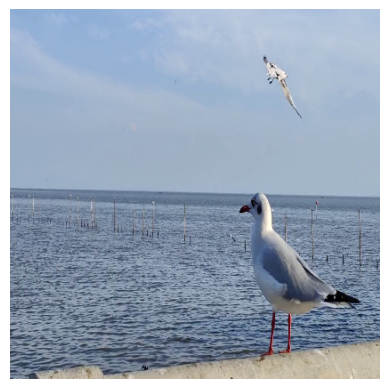

In [ ]:
# draw predicted boxes with confidence
def draw_predicted_boxes(image, pred_boxes, threshold, T=416):
    img_copy = image.copy()
    for i in range(3):
        for j in range(3):
            confidence = pred_boxes[i, j, 4]
            if confidence > threshold:
                x_min, y_min, x_max, y_max = pred_boxes[i, j, :4] * T
                cv2.rectangle(img_copy, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (255, 0, 0), 2) 
                cv2.putText(img_copy, f"Conf: {confidence:.2f}", (int(x_min), int(y_min)-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img_copy

videos_predicted = [draw_predicted_boxes(video_ds[i],y_pred_th[i],treshold) for i in range(len(video_ds))] # we store the frames



fig, ax = plt.subplots()
ax.imshow(videos_predicted[0])
ax.axis('off')

def update(frame):
    ax.clear()
    ax.imshow(videos_predicted[frame])
    ax.axis('off')

ani = FuncAnimation(fig, update, frames=len(videos_predicted), interval=1000/fps)  # for matter of visualisation we create a gif with the frames
ani.save("diaporama.gif", writer=PillowWriter(fps=fps))